In [6]:
import os
import json
import pandas as pd
import numpy as np

def aggregate_experiment_metrics(save_dir, names, method_name):
    all_summaries = []

    for name in names:
        # Construct path: save_dir/name/method_name/summary_metrics.json
        folder_path = os.path.join(save_dir, name, method_name)
        file_path = os.path.join(folder_path, "summary_metrics.json")

        if os.path.exists(file_path):
            with open(file_path, 'r') as f:
                metrics = json.load(f)
                metrics['style_name'] = name
                metrics['method'] = method_name
                all_summaries.append(metrics)
        else:
            print(f"Warning: File not found at {file_path}")

    if not all_summaries:
        return pd.DataFrame()

    # 1. Create the main DataFrame
    df = pd.DataFrame(all_summaries)
    
    # 2. Reorder columns to put style and method at the front
    cols = ['style_name', 'method'] + [c for c in df.columns if c not in ['style_name', 'method']]
    df = df[cols]

    # 3. Calculate Mean Row
    # Select only numeric columns for the calculation
    numeric_df = df.select_dtypes(include=[np.number])
    mean_values = numeric_df.mean()

    # 4. Create the summary row dictionary
    mean_row = {col: mean_values[col] for col in numeric_df.columns}
    mean_row['style_name'] = 'AVERAGE_ALL_STYLES'
    mean_row['method'] = method_name

    # 5. Append the row to the bottom
    df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)
    
    return df

# --- Usage ---
save_dir = 'experiments/flux_schnell/style/generated_images/'
names = ['cyberpunk', 'sketch', 'anime', 'impressionism']
method_name = '0_15'


# Optional: Highlighting the final row
# print(df_results.tail(1))

In [7]:
pd.set_option('display.max_rows', None)      # Show all rows
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', None)         # Don't wrap lines
pd.set_option('display.max_colwidth', None)  # Don't truncate cell content

In [8]:
for method_name in ['0_15', '0_2', '100_1_diff_m', '100_1_diff_s', '100_1_normals_s', '300_1_diff_m', '300_1_diff_s', '300_1_normals_s',
                    '1000_15_diff_m', '1000_15_diff_s', '1000_15_normals_s', 
                    '300_15_diff_m', '300_15_diff_s', '300_15_normals_s',
                    '300_15_diff_m_ssim', '300_15_diff_s_ssim', '1000_15_diff_m_ssim', '1000_15_diff_s_ssim' ]:
    print(method_name)
    df_results = aggregate_experiment_metrics(save_dir, names, method_name)
    pd.set_option('display.expand_frame_repr', False) 

# Ensure the width is large enough to hold all columns
    pd.set_option('display.width', 1000)
    print(df_results)
    print('------')

0_15
           style_name method  mean_clip_img_sim  mean_clip_score  mean_reward_score  mean_reward_score_origin  mean_clip_score_origin
0           cyberpunk   0_15           0.713725         0.204207           0.238617                  0.265622                0.085515
1              sketch   0_15           0.763216         0.135543           0.258264                  0.265622                0.077158
2               anime   0_15           0.785242         0.122317           0.257957                  0.265622                0.081271
3       impressionism   0_15           0.727842         0.095149           0.255194                  0.265622                0.065239
4  AVERAGE_ALL_STYLES   0_15           0.747506         0.139304           0.252508                  0.265622                0.077296
------
0_2
           style_name method  mean_clip_img_sim  mean_clip_score  mean_reward_score  mean_reward_score_origin  mean_clip_score_origin
0           cyberpunk    0_2           0.63298

In [32]:
save_dir = 'experiments/flux_schnell/add/generated_images/'
names = ['hat', 'glasses', 'apple', 'lipstick']

In [33]:
for method_name in ['0_15', '0_2', '100_1_diff_m', '100_1_diff_s', '100_1_normals_s', 
                    '300_1_diff_m', '300_1_diff_s', '300_1_normals_s',
                    '1000_1_diff_m', '1000_1_diff_s', '1000_1_normals_s',
                    '1000_1_diff_m_ssim', '1000_1_diff_s_ssim', '1000_1_normals_s_ssim',
                    ]:
    print(method_name)
    df_results = aggregate_experiment_metrics(save_dir, names, method_name)
    pd.set_option('display.expand_frame_repr', False) 

# Ensure the width is large enough to hold all columns
    pd.set_option('display.width', 1000)
    print(df_results)
    print('------')

0_15
           style_name method  mean_clip_img_sim  mean_clip_score  mean_reward_score  mean_reward_score_origin  mean_clip_score_origin
0                 hat   0_15           0.824351         0.175224           0.257086                   0.26739                0.133744
1             glasses   0_15           0.890673         0.159635           0.254695                   0.26739                0.116052
2               apple   0_15           0.878144         0.140587           0.260374                   0.26739                0.133844
3            lipstick   0_15           0.887217         0.125408           0.271341                   0.26739                0.109450
4  AVERAGE_ALL_STYLES   0_15           0.870096         0.150213           0.260874                   0.26739                0.123273
------
0_2
           style_name method  mean_clip_img_sim  mean_clip_score  mean_reward_score  mean_reward_score_origin  mean_clip_score_origin
0                 hat    0_2           0.78675

In [76]:
import os
import json
import pandas as pd
import numpy as np

def aggregate_dino_metrics(save_dir, names, method_name):
    all_summaries = []

    for name in names:
        # Construct path: save_dir/name/method_name/metrics.json
        folder_path = os.path.join(save_dir, name, method_name, 'dino')
        file_path = os.path.join(folder_path, "metrics.json")

        if os.path.exists(file_path):
            with open(file_path, 'r') as f:
                metrics = json.load(f)
                
                # Add metadata for identification
                metrics['style_name'] = name
                metrics['method'] = method_name
                all_summaries.append(metrics)
        else:
            print(f"Warning: File not found at {file_path}")

    if not all_summaries:
        print("No metrics found. Check your paths.")
        return pd.DataFrame()

    # 1. Create DataFrame
    df = pd.DataFrame(all_summaries)
    
    # 2. Reorder columns (metadata first)
    cols = ['style_name', 'method'] + [c for c in df.columns if c not in ['style_name', 'method']]
    df = df[cols]

    # 3. Calculate Mean Row (Detection Rate Average)
    numeric_df = df.select_dtypes(include=[np.number])
    mean_values = numeric_df.mean()

    # 4. Create and Append the AVERAGE row
    mean_row = {col: mean_values[col] for col in numeric_df.columns}
    mean_row['style_name'] = 'AVERAGE_ALL_STYLES'
    mean_row['method'] = method_name

    df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)
    
    return df

# --- Configuration ---
# Match these to your actual directory structure
save_dir = 'experiments/flux_schnell/add/generated_images/'
names = ['apple', 'glasses', 'hat', 'lipstick']
method_name = '0_1'

# Set pandas display options to prevent truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', 1000)

for method_name in ['0_15', '0_2', '100_1_diff_m', '100_1_diff_s', '100_1_normals_s', 
                    '300_1_diff_m', '300_1_diff_s', '300_1_normals_s',
                    '1000_1_diff_m', '1000_1_diff_s', '1000_1_normals_s',
                    '1000_1_diff_m_ssim', '1000_1_diff_s_ssim', '1000_1_normals_s_ssim',
                    ]:
    print(method_name)
    df_results = aggregate_dino_metrics(save_dir, names, method_name)
    pd.set_option('display.expand_frame_repr', False) 

# Ensure the width is large enough to hold all columns
    pd.set_option('display.width', 1000)
    print(df_results)
    print('------')
# Optional: Save to CSV
# df_dino_results.to_csv(os.path.join(save_dir, f"dino_comparison_{method_name}.csv"), index=False)

0_15
           style_name method  detection_rate
0               apple   0_15        0.206897
1             glasses   0_15        0.793103
2                 hat   0_15        0.620690
3            lipstick   0_15        0.758621
4  AVERAGE_ALL_STYLES   0_15        0.594828
------
0_2
           style_name method  detection_rate
0               apple    0_2        0.586207
1             glasses    0_2        0.896552
2                 hat    0_2        0.896552
3            lipstick    0_2        0.827586
4  AVERAGE_ALL_STYLES    0_2        0.801724
------
100_1_diff_m
           style_name        method  detection_rate
0               apple  100_1_diff_m        0.103448
1             glasses  100_1_diff_m        0.655172
2                 hat  100_1_diff_m        0.689655
3            lipstick  100_1_diff_m        0.758621
4  AVERAGE_ALL_STYLES  100_1_diff_m        0.551724
------
100_1_diff_s
           style_name        method  detection_rate
0               apple  100_1_diff_s     

# Plots

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for nicer plots
sns.set(style="whitegrid", font_scale=1.2)

# ==================== DATA ====================
# All the data from your latest message (cyberpunk + sketch + anime + impressionism + average)
data = [
    # method, style, mean_clip_score, mean_reward_score
    ("0_0", "cyberpunk", 0.085515, 0.265622),
    ("0_0", "sketch", 0.077158, 0.265622),
    ("0_0", "anime", 0.081271, 0.265622),
    ("0_0", "impressionism", 0.065239, 0.265622),
    ("0_0", "AVERAGE_ALL_STYLES", 0.077296, 0.265622),
    

    ("0_15", "cyberpunk", 0.204207, 0.238617),
    ("0_15", "sketch", 0.135543, 0.258264),
    ("0_15", "anime", 0.122317, 0.257957),
    ("0_15", "impressionism", 0.095149, 0.255194),
    ("0_15", "AVERAGE_ALL_STYLES", 0.139304, 0.252508),
    
    ("0_2", "cyberpunk", 0.238622, 0.201845),
    ("0_2", "sketch", 0.184469, 0.232283),
    ("0_2", "anime", 0.153943, 0.231897),
    ("0_2", "impressionism", 0.105967, 0.242880),
    ("0_2", "AVERAGE_ALL_STYLES", 0.170750, 0.227226),
    
    ("100_1_diff_m", "cyberpunk", 0.180708, 0.249763),
    ("100_1_diff_m", "sketch", 0.120314, 0.269331),
    ("100_1_diff_m", "anime", 0.111598, 0.265482),
    ("100_1_diff_m", "impressionism", 0.086060, 0.266347),
    ("100_1_diff_m", "AVERAGE_ALL_STYLES", 0.124670, 0.262731),
    
    ("100_1_diff_s", "cyberpunk", 0.190399, 0.251472),
    ("100_1_diff_s", "sketch", 0.127959, 0.263071),
    ("100_1_diff_s", "anime", 0.115785, 0.257356),
    ("100_1_diff_s", "impressionism", 0.091853, 0.262257),
    ("100_1_diff_s", "AVERAGE_ALL_STYLES", 0.131499, 0.258539),
    
    ("100_1_normals_s", "cyberpunk", 0.182622, 0.252275),
    ("100_1_normals_s", "AVERAGE_ALL_STYLES", 0.182622, 0.252275),
    # missing for sketch/anime/impressionism
    
    ("300_1_diff_m", "cyberpunk", 0.197063, 0.246094),
    ("300_1_diff_m", "sketch", 0.135419, 0.255648),
    ("300_1_diff_m", "anime", 0.116521, 0.266582),
    ("300_1_diff_m", "impressionism", 0.092848, 0.267471),
    ("300_1_diff_m", "AVERAGE_ALL_STYLES", 0.135463, 0.258949),
    
    ("300_1_diff_s", "cyberpunk", 0.206506, 0.239221),
    ("300_1_diff_s", "sketch", 0.159870, 0.256825),
    ("300_1_diff_s", "anime", 0.129936, 0.260324),
    ("300_1_diff_s", "impressionism", 0.092028, 0.259797),
    ("300_1_diff_s", "AVERAGE_ALL_STYLES", 0.147085, 0.254042),
    
    ("300_1_normals_s", "cyberpunk", 0.196276, 0.245938),
    ("300_1_normals_s", "sketch", 0.132975, 0.261808),
    ("300_1_normals_s", "anime", 0.117105, 0.264770),
    ("300_1_normals_s", "impressionism", 0.088134, 0.267611),
    ("300_1_normals_s", "AVERAGE_ALL_STYLES", 0.133623, 0.260032),
    
    ("1000_15_diff_m", "cyberpunk", 0.250241, 0.208776),
    ("1000_15_diff_m", "sketch", 0.187717, 0.228094),
    ("1000_15_diff_m", "anime", 0.143017, 0.236237),
    ("1000_15_diff_m", "impressionism", 0.113015, 0.248425),
    ("1000_15_diff_m", "AVERAGE_ALL_STYLES", 0.173497, 0.230383),
    
    ("1000_15_diff_s", "cyberpunk", 0.257054, 0.206384),
    ("1000_15_diff_s", "sketch", 0.202263, 0.225916),
    ("1000_15_diff_s", "anime", 0.166530, 0.214509),
    ("1000_15_diff_s", "impressionism", 0.108341, 0.237147),
    ("1000_15_diff_s", "AVERAGE_ALL_STYLES", 0.183547, 0.220989),
    
    ("1000_15_normals_s", "cyberpunk", 0.252151, 0.210670),
    ("1000_15_normals_s", "sketch", 0.186376, 0.225144),
    ("1000_15_normals_s", "anime", 0.139562, 0.240515),
    ("1000_15_normals_s", "impressionism", 0.112201, 0.248125),
    ("1000_15_normals_s", "AVERAGE_ALL_STYLES", 0.172572, 0.231113),
    
    ("300_15_diff_m", "cyberpunk", 0.241018, 0.208510),
    ("300_15_diff_m", "sketch", 0.180487, 0.232871),
    ("300_15_diff_m", "anime", 0.135294, 0.240073),
    ("300_15_diff_m", "impressionism", 0.107840, 0.248606),
    ("300_15_diff_m", "AVERAGE_ALL_STYLES", 0.166160, 0.232515),
    
    ("300_15_diff_s", "cyberpunk", 0.249663, 0.206345),
    ("300_15_diff_s", "sketch", 0.188729, 0.227009),
    ("300_15_diff_s", "anime", 0.161029, 0.221957),
    ("300_15_diff_s", "impressionism", 0.112666, 0.238643),
    ("300_15_diff_s", "AVERAGE_ALL_STYLES", 0.178022, 0.223488),
    
    ("300_15_normals_s", "cyberpunk", 0.242326, 0.217229),
    ("300_15_normals_s", "sketch", 0.179766, 0.231911),
    ("300_15_normals_s", "anime", 0.136290, 0.245613),
    ("300_15_normals_s", "impressionism", 0.108454, 0.249170),
    ("300_15_normals_s", "AVERAGE_ALL_STYLES", 0.166709, 0.235981),
    
    ("300_15_diff_m_ssim", "cyberpunk", 0.205114, 0.239193),
    ("300_15_diff_m_ssim", "sketch", 0.139128, 0.259514),
    ("300_15_diff_m_ssim", "anime", 0.118850, 0.261086),
    ("300_15_diff_m_ssim", "impressionism", 0.096020, 0.253558),
    ("300_15_diff_m_ssim", "AVERAGE_ALL_STYLES", 0.139778, 0.253338),
    
    ("300_15_diff_s_ssim", "cyberpunk", 0.204057, 0.234573),
    ("300_15_diff_s_ssim", "sketch", 0.135028, 0.258005),
    ("300_15_diff_s_ssim", "anime", 0.122624, 0.259932),
    ("300_15_diff_s_ssim", "impressionism", 0.095740, 0.251952),
    ("300_15_diff_s_ssim", "AVERAGE_ALL_STYLES", 0.139362, 0.251116),
    
    ("1000_15_diff_m_ssim", "cyberpunk", 0.204632, 0.240346),
    ("1000_15_diff_m_ssim", "sketch", 0.137493, 0.256548),
    ("1000_15_diff_m_ssim", "anime", 0.120890, 0.258053),
    ("1000_15_diff_m_ssim", "impressionism", 0.096159, 0.252546),
    ("1000_15_diff_m_ssim", "AVERAGE_ALL_STYLES", 0.139794, 0.251873),
    
    ("1000_15_diff_s_ssim", "cyberpunk", 0.205387, 0.239064),
    ("1000_15_diff_s_ssim", "sketch", 0.137607, 0.257888),
    ("1000_15_diff_s_ssim", "anime", 0.121116, 0.259328),
    ("1000_15_diff_s_ssim", "impressionism", 0.095936, 0.252321),
    ("1000_15_diff_s_ssim", "AVERAGE_ALL_STYLES", 0.140012, 0.252150),
]

# Create DataFrame
df = pd.DataFrame(data, columns=["method", "style", "mean_clip_score", "mean_reward_score"])

# ==================== PLOTTING FUNCTION ====================
def plot_clip_vs_reward(method: str, style: str):
    """
    Plot mean_clip_score (x) vs mean_reward_score (y) for a specific method and style.
    
    Parameters:
        method (str): e.g. "0_15", "100_1_diff_m", "300_15_diff_m_ssim", etc.
        style (str): "cyberpunk", "sketch", "anime", "impressionism", or "AVERAGE_ALL_STYLES"
    """
    subset = df[(df["method"] == method) & (df["style"] == style)]
    
    if subset.empty:
        print(f"No data found for method='{method}' and style='{style}'")
        return
    
    x = subset["mean_clip_score"].values[0]
    y = subset["mean_reward_score"].values[0]
    
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, s=100, c='red', label=f"{method} - {style}")
    plt.xlim(0.08, 0.28)
    plt.ylim(0.19, 0.28)
    plt.xlabel("Mean CLIP Score")
    plt.ylabel("Mean Reward Score")
    plt.title(f"CLIP Score vs Reward Score\nMethod: {method} | Style: {style}")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    



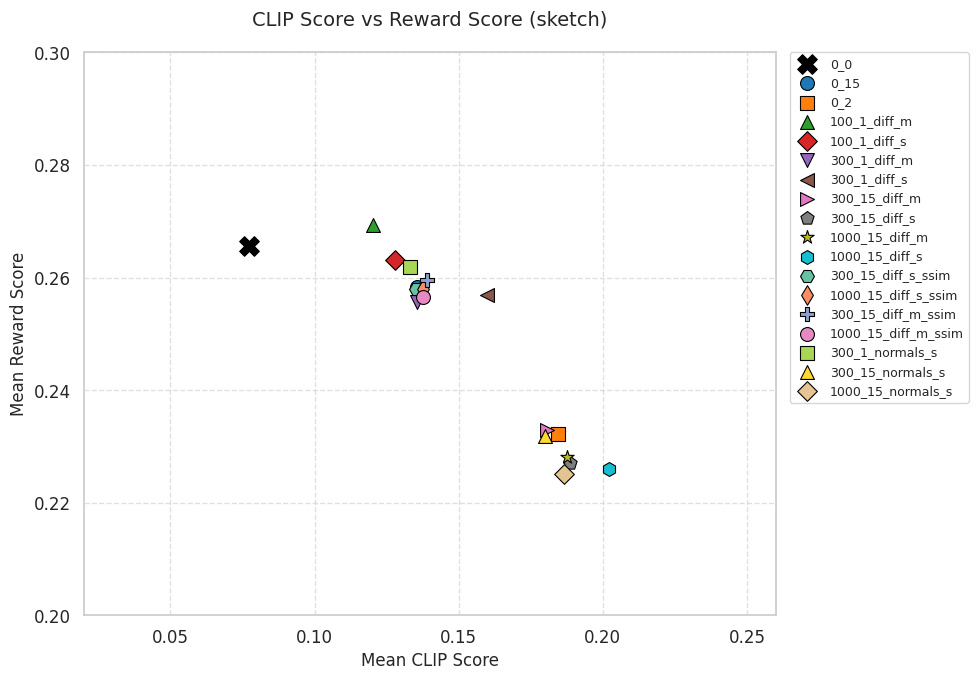

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Optional: nicer overall style
style = 'AVERAGE_ALL_STYLES'
sns.set(style="whitegrid", font_scale=1.1)

# Your data (assuming df is already created as in previous code)
# df = pd.DataFrame(data, columns=["method", "style", "mean_clip_score", "mean_reward_score"])

methods = [
    "0_15", "0_2",
    "100_1_diff_m", "100_1_diff_s",
    "300_1_diff_m", "300_1_diff_s",
    "300_15_diff_m", "300_15_diff_s",
    "1000_15_diff_m", "1000_15_diff_s",
    '300_15_diff_s_ssim', '1000_15_diff_s_ssim',
    '300_15_diff_m_ssim', '1000_15_diff_m_ssim',
    "300_1_normals_s", "300_15_normals_s", "1000_15_normals_s"
]

style = "sketch"  # You can change to "cyberpunk", "sketch", etc.

# Color-blind-friendly palette (distinct even in black/white)
colors = sns.color_palette("tab10", n_colors=10) + sns.color_palette("Set2", n_colors=8)

# Different markers for extra clarity when colors are similar
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', 'd', 'P']

plt.figure(figsize=(10, 7))


subset = df[(df["method"] == "0_0") & (df["style"] == style)]
    
    

x = subset["mean_clip_score"].values[0]
y = subset["mean_reward_score"].values[0]

plt.scatter(x, y, s=200, c='black', marker='X', label="0_0", edgecolors='black', linewidth=0.8)

# Legend: outside the plot to avoid crowding
plt.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)


for i, method in enumerate(methods):
    subset = df[(df["method"] == method) & (df["style"] == style)]
    
    if subset.empty:
        print(f"Missing data: method='{method}', style='{style}'")
        continue
    
    x = subset["mean_clip_score"].values[0]
    y = subset["mean_reward_score"].values[0]
    
    color = colors[i % len(colors)]
    marker = markers[i % len(markers)]
    
    plt.scatter(x, y, s=100, c=[color], marker=marker, label=method, edgecolors='black', linewidth=0.8)

# Customizations
plt.xlim(0.02, 0.26)   # Adjusted to better fit your data range
plt.ylim(0.2, 0.3)

plt.xlabel("Mean CLIP Score", fontsize=12)
plt.ylabel("Mean Reward Score", fontsize=12)
plt.title(f"CLIP Score vs Reward Score ({style})", fontsize=14, pad=20)

# Legend: outside the plot to avoid crowding
plt.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)

# ==================== FULL DATA (all styles and methods) ====================
data = [
    # method, style, mean_clip_score, mean_reward_score
    





    ("0_0", "hat", 0.133744, 0.26739 ),
    ("0_0", "glasses", 0.116052, 0.26739),
    ("0_0", "apple", 0.133844, 0.26739),
    ("0_0", "lipstick", 0.109450, 0.26739),
    ("0_0", "AVERAGE_ALL_STYLES", 0.123273, 0.26739),


    ("0_15", "hat", 0.175224, 0.257086),
    ("0_15", "glasses", 0.159635, 0.254695),
    ("0_15", "apple", 0.140587, 0.260374),
    ("0_15", "lipstick", 0.125408, 0.271341),
    ("0_15", "AVERAGE_ALL_STYLES", 0.150213, 0.260874),
    
    ("0_2", "hat", 0.199653, 0.243738),
    ("0_2", "glasses", 0.180834, 0.247588),
    ("0_2", "apple", 0.168365, 0.246050),
    ("0_2", "lipstick", 0.149698, 0.267569),
    ("0_2", "AVERAGE_ALL_STYLES", 0.174637, 0.251236),
    
    ("100_1_diff_m", "hat", 0.161879, 0.265206),
    ("100_1_diff_m", "glasses", 0.153009, 0.256249),
    ("100_1_diff_m", "apple", 0.135699, 0.266984),
    ("100_1_diff_m", "lipstick", 0.136503, 0.265493),
    ("100_1_diff_m", "AVERAGE_ALL_STYLES", 0.146773, 0.263483),
    
    ("100_1_diff_s", "hat", 0.167564, 0.260329),
    ("100_1_diff_s", "glasses", 0.159438, 0.253782),
    ("100_1_diff_s", "apple", 0.137082, 0.262907),
    ("100_1_diff_s", "lipstick", 0.140346, 0.265417),
    ("100_1_diff_s", "AVERAGE_ALL_STYLES", 0.151107, 0.260609),
    
    ("100_1_normals_s", "hat", 0.164708, 0.259845),
    ("100_1_normals_s", "glasses", 0.154692, 0.257620),
    ("100_1_normals_s", "apple", 0.135939, 0.263802),
    ("100_1_normals_s", "lipstick", 0.140192, 0.265694),
    ("100_1_normals_s", "AVERAGE_ALL_STYLES", 0.148883, 0.261740),
    
    ("300_1_diff_m", "hat", 0.167427, 0.254865),
    ("300_1_diff_m", "glasses", 0.159978, 0.243242),
    ("300_1_diff_m", "apple", 0.137628, 0.266388),
    ("300_1_diff_m", "lipstick", 0.147695, 0.258735),
    ("300_1_diff_m", "AVERAGE_ALL_STYLES", 0.153182, 0.255807),
    
    ("300_1_diff_s", "hat", 0.169474, 0.256740),
    ("300_1_diff_s", "glasses", 0.162767, 0.244269),
    ("300_1_diff_s", "apple", 0.137181, 0.264263),
    ("300_1_diff_s", "lipstick", 0.160892, 0.250067),
    ("300_1_diff_s", "AVERAGE_ALL_STYLES", 0.157579, 0.253835),
    
    ("300_1_normals_s", "hat", 0.168166, 0.253084),
    ("300_1_normals_s", "glasses", 0.158021, 0.245602),
    ("300_1_normals_s", "apple", 0.139151, 0.267292),
    ("300_1_normals_s", "lipstick", 0.153662, 0.261151),
    ("300_1_normals_s", "AVERAGE_ALL_STYLES", 0.154750, 0.256782),
    
    ("1000_1_diff_m", "hat", 0.171131, 0.249557),
    ("1000_1_diff_m", "glasses", 0.167625, 0.241805),
    ("1000_1_diff_m", "apple", 0.138144, 0.254401),
    ("1000_1_diff_m", "lipstick", 0.152345, 0.243621),
    ("1000_1_diff_m", "AVERAGE_ALL_STYLES", 0.157311, 0.247346),
    
    ("1000_1_diff_s", "hat", 0.181836, 0.243251),
    ("1000_1_diff_s", "glasses", 0.159968, 0.236212),
    ("1000_1_diff_s", "apple", 0.136381, 0.255767),
    ("1000_1_diff_s", "lipstick", 0.174958, 0.233260),
    ("1000_1_diff_s", "AVERAGE_ALL_STYLES", 0.163286, 0.242123),
    
    ("1000_1_normals_s", "hat", 0.165217, 0.251299),
    ("1000_1_normals_s", "glasses", 0.165736, 0.241996),
    ("1000_1_normals_s", "apple", 0.141275, 0.254016),
    ("1000_1_normals_s", "lipstick", 0.151881, 0.243257),
    ("1000_1_normals_s", "AVERAGE_ALL_STYLES", 0.156027, 0.247642),
    
    ("1000_1_diff_m_ssim", "hat", 0.152841, 0.260354),
    ("1000_1_diff_m_ssim", "glasses", 0.136179, 0.264983),
    ("1000_1_diff_m_ssim", "apple", 0.134737, 0.265573),
    ("1000_1_diff_m_ssim", "lipstick", 0.121123, 0.270964),
    ("1000_1_diff_m_ssim", "AVERAGE_ALL_STYLES", 0.136220, 0.265468),
    
    ("1000_1_diff_s_ssim", "hat", 0.147336, 0.259099),
    ("1000_1_diff_s_ssim", "glasses", 0.134087, 0.263569),
    ("1000_1_diff_s_ssim", "apple", 0.135844, 0.265250),
    ("1000_1_diff_s_ssim", "lipstick", 0.122719, 0.271659),
    ("1000_1_diff_s_ssim", "AVERAGE_ALL_STYLES", 0.134997, 0.264894),
    
    ("1000_1_normals_s_ssim", "hat", 0.154354, 0.261644),
    ("1000_1_normals_s_ssim", "glasses", 0.136745, 0.266267),
    ("1000_1_normals_s_ssim", "apple", 0.135332, 0.263470),
    ("1000_1_normals_s_ssim", "lipstick", 0.121581, 0.270790),
    ("1000_1_normals_s_ssim", "AVERAGE_ALL_STYLES", 0.137003, 0.265543),
]

df = pd.DataFrame(data, columns=["method", "style", "mean_clip_score", "mean_reward_score"])


In [59]:
df.head()

,method,style,mean_clip_score,mean_reward_score
0,0_0,hat,0.133744,0.26739
1,0_0,glasses,0.116052,0.26739
2,0_0,apple,0.133844,0.26739
3,0_0,lipstick,0.109450,0.26739
4,0_0,AVERAGE_ALL_STYLES,0.123273,0.26739


In [60]:
subset

,method,style,mean_clip_score,mean_reward_score


In [56]:
save_dir = 'experiments/flux_schnell/add/generated_images/'
names = ['hat', 'glasses', 'apple', 'lipstick']

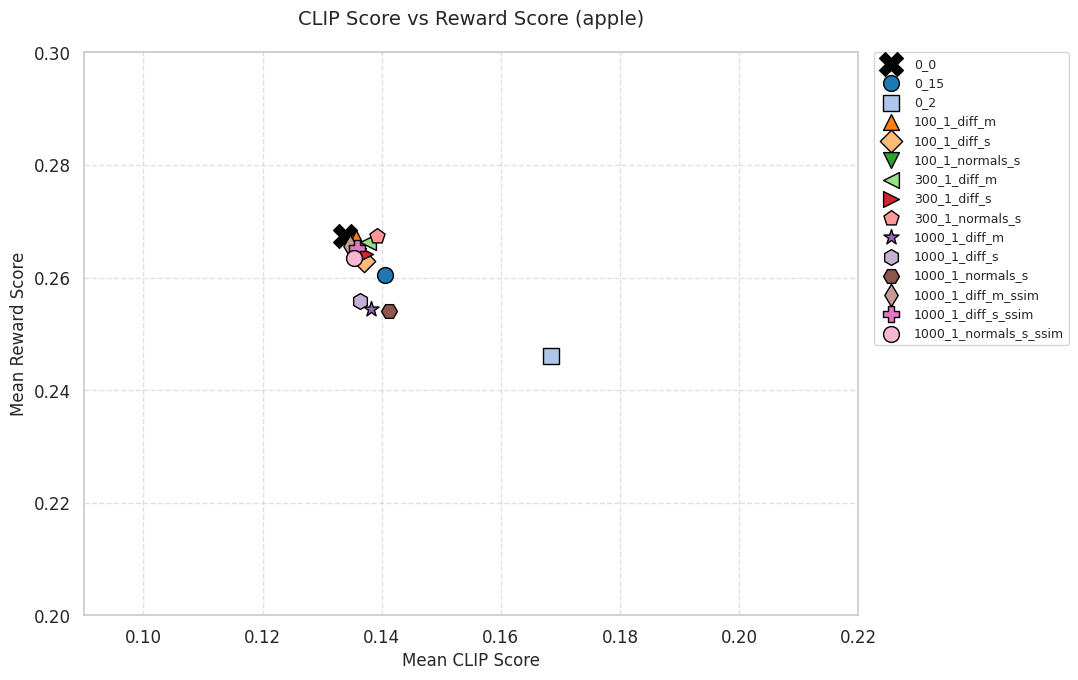

In [71]:

methods = [

    "0_15", "0_2",
    "100_1_diff_m", "100_1_diff_s", "100_1_normals_s",
    "300_1_diff_m", "300_1_diff_s", "300_1_normals_s",
    "1000_1_diff_m", "1000_1_diff_s", "1000_1_normals_s",
    "1000_1_diff_m_ssim", "1000_1_diff_s_ssim", "1000_1_normals_s_ssim"
]

# ==================== CHOOSE STYLE HERE ====================
style = "apple"  # Change to: "hat", "glasses", "lipstick", or "AVERAGE_ALL_STYLES"

# ==================== PLOT ====================
plt.figure(figsize=(11, 7))

# Color-blind-friendly palette + plenty of markers
colors = sns.color_palette("tab20", n_colors=len(methods))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', 'd', 'P',]

subset = df[(df["method"] == "0_0") & (df["style"] == style)]

x = subset["mean_clip_score"].values[0]
y = subset["mean_reward_score"].values[0]

plt.scatter(x, y, s=300, c='black', marker='X', label="0_0", edgecolors='black', linewidth=0.8)

# Legend: outside the plot to avoid crowding
plt.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

for i, method in enumerate(methods):
    subset = df[(df["method"] == method) & (df["style"] == style)]
    
    if subset.empty:
        print(f"Missing data: {method} - {chosen_style}")
        continue
    
    x = subset["mean_clip_score"].values[0]
    y = subset["mean_reward_score"].values[0]
    
    plt.scatter(x, y, s=130, c=[colors[i]], marker=markers[i % len(markers)],
                label=method, edgecolors='black', linewidth=1)

# Axis limits tuned to this dataset
plt.xlim(0.09, 0.22)
plt.ylim(0.2, 0.3)

plt.xlabel("Mean CLIP Score", fontsize=12)
plt.ylabel("Mean Reward Score", fontsize=12)
plt.title(f"CLIP Score vs Reward Score ({style})", fontsize=14, pad=20)

# Legend outside to avoid overlap
plt.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)

# ==================== UPDATED GROUNDING DINO + REWARD DATA ====================
data = [
    # method, style, detection_rate, mean_reward_score (from previous CLIP/reward data)
    ("0_15", "apple", 0.206897, 0.260374),
    ("0_15", "glasses", 0.793103, 0.254695),
    ("0_15", "hat", 0.620690, 0.257086),
    ("0_15", "lipstick", 0.758621, 0.271341),
    ("0_15", "AVERAGE_ALL_STYLES", 0.594828, 0.260874),
    
    ("0_2", "apple", 0.586207, 0.246050),
    ("0_2", "glasses", 0.896552, 0.247588),
    ("0_2", "hat", 0.896552, 0.243738),
    ("0_2", "lipstick", 0.827586, 0.267569),
    ("0_2", "AVERAGE_ALL_STYLES", 0.801724, 0.251236),
    
    ("100_1_diff_m", "apple", 0.103448, 0.266984),
    ("100_1_diff_m", "glasses", 0.655172, 0.256249),
    ("100_1_diff_m", "hat", 0.689655, 0.265206),
    ("100_1_diff_m", "lipstick", 0.758621, 0.265493),
    ("100_1_diff_m", "AVERAGE_ALL_STYLES", 0.551724, 0.263483),
    
    ("100_1_diff_s", "apple", 0.068966, 0.262907),
    ("100_1_diff_s", "glasses", 0.758621, 0.253782),
    ("100_1_diff_s", "hat", 0.655172, 0.260329),
    ("100_1_diff_s", "lipstick", 0.655172, 0.265417),
    ("100_1_diff_s", "AVERAGE_ALL_STYLES", 0.534483, 0.260609),
    
    ("100_1_normals_s", "apple", 0.103448, 0.263802),
    ("100_1_normals_s", "glasses", 0.689655, 0.257620),
    ("100_1_normals_s", "hat", 0.689655, 0.259845),
    ("100_1_normals_s", "lipstick", 0.689655, 0.265694),
    ("100_1_normals_s", "AVERAGE_ALL_STYLES", 0.543103, 0.261740),
    
    ("300_1_diff_m", "glasses", 0.793103, 0.243242),
    ("300_1_diff_m", "hat", 0.586207, 0.254865),
    ("300_1_diff_m", "lipstick", 0.758621, 0.258735),
    ("300_1_diff_m", "AVERAGE_ALL_STYLES", 0.712644, 0.255807),
    
    ("300_1_diff_s", "glasses", 0.793103, 0.244269),
    ("300_1_diff_s", "hat", 0.655172, 0.256740),
    ("300_1_diff_s", "lipstick", 0.689655, 0.250067),
    ("300_1_diff_s", "AVERAGE_ALL_STYLES", 0.712644, 0.253835),
    
    ("300_1_normals_s", "glasses", 0.758621, 0.245602),
    ("300_1_normals_s", "hat", 0.655172, 0.253084),
    ("300_1_normals_s", "lipstick", 0.793103, 0.261151),
    ("300_1_normals_s", "AVERAGE_ALL_STYLES", 0.735632, 0.256782),
    
    ("1000_1_diff_m", "apple", 0.103448, 0.254401),
    ("1000_1_diff_m", "glasses", 0.793103, 0.241805),
    ("1000_1_diff_m", "hat", 0.620690, 0.249557),
    ("1000_1_diff_m", "lipstick", 0.758621, None),  # reward not in previous data, skipped
    ("1000_1_diff_m", "AVERAGE_ALL_STYLES", 0.568966, 0.247346),
    
    ("1000_1_diff_s", "apple", 0.103448, 0.255767),
    ("1000_1_diff_s", "glasses", 0.758621, 0.236212),
    ("1000_1_diff_s", "hat", 0.758621, 0.243251),
    ("1000_1_diff_s", "lipstick", 0.724138, None),
    ("1000_1_diff_s", "AVERAGE_ALL_STYLES", 0.586207, 0.242123),
    
    ("1000_1_normals_s", "apple", 0.137931, 0.254016),
    ("1000_1_normals_s", "glasses", 0.793103, 0.241996),
    ("1000_1_normals_s", "hat", 0.655172, 0.251299),
    ("1000_1_normals_s", "lipstick", 0.793103, 0.243257),
    ("1000_1_normals_s", "AVERAGE_ALL_STYLES", 0.594828, 0.247642),
    
    ("1000_1_diff_m_ssim", "apple", 0.034483, 0.265573),
    ("1000_1_diff_m_ssim", "glasses", 0.413793, 0.264983),
    ("1000_1_diff_m_ssim", "hat", 0.310345, 0.260354),
    ("1000_1_diff_m_ssim", "lipstick", 0.758621, 0.270964),
    ("1000_1_diff_m_ssim", "AVERAGE_ALL_STYLES", 0.379310, 0.265468),
    
    ("1000_1_diff_s_ssim", "apple", 0.068966, 0.265250),
    ("1000_1_diff_s_ssim", "glasses", 0.379310, 0.263569),
    ("1000_1_diff_s_ssim", "hat", 0.344828, 0.259099),
    ("1000_1_diff_s_ssim", "lipstick", 0.724138, 0.271659),
    ("1000_1_diff_s_ssim", "AVERAGE_ALL_STYLES", 0.379310, 0.264894),
    
    ("1000_1_normals_s_ssim", "apple", 0.000000, 0.263470),
    ("1000_1_normals_s_ssim", "glasses", 0.413793, 0.266267),
    ("1000_1_normals_s_ssim", "hat", 0.448276, 0.261644),
    ("1000_1_normals_s_ssim", "lipstick", 0.655172, 0.270790),
    ("1000_1_normals_s_ssim", "AVERAGE_ALL_STYLES", 0.379310, 0.265543),
]

df = pd.DataFrame(data, columns=["method", "style", "detection_rate", "mean_reward_score"])
df = df.dropna(subset=["mean_reward_score"])  # Remove any missing reward entries

# ==================== METHODS TO PLOT ====================
methods = [
    "0_15", "0_2",
    "100_1_diff_m", "100_1_diff_s", "100_1_normals_s",
    "300_1_diff_m", "300_1_diff_s", "300_1_normals_s",
    "1000_1_diff_m", "1000_1_diff_s", "1000_1_normals_s",
    "1000_1_diff_m_ssim", "1000_1_diff_s_ssim", "1000_1_normals_s_ssim"
]

# ==================== CHOOSE STYLE HERE ====================
chosen_style = "AVERAGE_ALL_STYLES"  # Options: "apple", "glasses", "hat", "lipstick", "AVERAGE_ALL_STYLES"


/tmp/ipykernel_3681441/1591753431.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)


Missing data: 300_1_diff_m - AVERAGE_ALL_STYLES
Missing data: 300_1_diff_s - AVERAGE_ALL_STYLES
Missing data: 300_1_normals_s - AVERAGE_ALL_STYLES


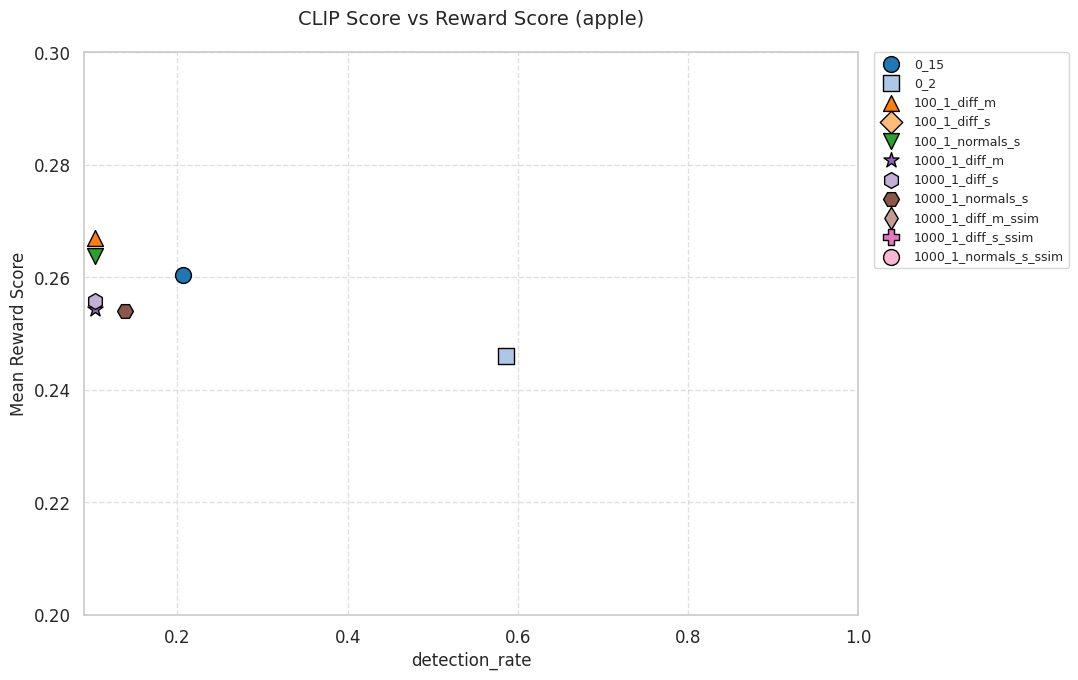

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Your Data Structures
gd_results = { ... } # Your provided Grounding DINO dict
clip_results = { ... } # Your CLIP dict

# 2. Setup Plotting Parameters
dirs = ['all', 'first_7', 'first_9', 'first_12']
thresholds = ['0.25', '0.5', '0.75']

color_map = {'all': 'tab:red', 'first_7': 'tab:blue', 'first_9': 'tab:green', 'first_12': 'tab:orange'}
marker_map = {'0.25': 'o', '0.5': 's', '0.75': '^'}

# 3. Create Plots for each Concept
for concept in gd_results:
    plt.figure(figsize=(10, 7))
    
    # Iterate through every data point
    for thresh in thresholds:
        for i, d in enumerate(dirs):
            x = gd_results[concept][thresh][i]
            y = clip_results[concept][thresh][i]
            
            plt.scatter(x, y, 
                        color=color_map[d], 
                        marker=marker_map[thresh], 
                        s=150, 
                        edgecolors='black', 
                        alpha=0.8, 
                        zorder=3)
    
    # Define Custom Legends
    color_legend = [Line2D([0], [0], marker='o', color='w', label=d,
                           markerfacecolor=color_map[d], markersize=10, markeredgecolor='k') for d in dirs]
    
    marker_legend = [Line2D([0], [0], marker=marker_map[t], color='w', label=f'Threshold {t}',
                            markerfacecolor='gray', markersize=10, markeredgecolor='k') for t in thresholds]
    
    # Place Legends outside the plot
    l1 = plt.legend(handles=color_legend, title="Directories (Colors)", loc='upper left', bbox_to_anchor=(1, 1))
    plt.gca().add_artist(l1)
    plt.legend(handles=marker_legend, title="Thresholds (Markers)", loc='lower left', bbox_to_anchor=(1, 0))

    # Styling
    plt.title(f"Comparison for Concept: {concept.capitalize()}")
    plt.xlabel("Grounding DINO Detection Rate")
    plt.ylabel("CLIP Metric")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.savefig(f"combined_plot_{concept}.png")

# Dino-gs

In [13]:
import os
import json

def get_metrics_dict(dirs_list, thresholds, concept_name="dino_performance"):
    
    result_dict = {}
    
        
        # Construct path: folder/dino/metrics_{threshold}.json
    for threshold in thresholds:
        detection_rates = []
        for folder in dirs_list:
            file_path = os.path.join(folder, "dino", f"metrics_{threshold}.json")
            
            try:
                if os.path.exists(file_path):
                    with open(file_path, 'r') as f:
                        data = json.load(f)
                        # Extract the rate and append to our list
                        rate = data.get("detection_rate")
                        detection_rates.append(rate)
                else:
                    print(f"Warning: {file_path} not found.")
                    detection_rates.append(None)
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                detection_rates.append(None)

            result_dict[threshold] = detection_rates
            

    # Return the final dictionary structure
    return result_dict



## blocks

In [14]:
# --- Usage ---
directories = ["experiments/flux_schnell/add/generated_images/smile/1000_15_mean_diff_s_only_pooled/", 
               "experiments/flux_schnell/add/generated_images/smile/1000_15_mean_diff_s_only_pooled_0_7/",
               "experiments/flux_schnell/add/generated_images/smile/1000_15_mean_diff_s_only_pooled_0_9/", 
               "experiments/flux_schnell/add/generated_images/smile/1000_15_mean_diff_s_only_pooled_0_12/"]
my_thresholds = ["0.25", "0.5", "0.75"] # example threshold

final_dict = get_metrics_dict(directories, my_thresholds, concept_name="hat_grounding_dino")
print(final_dict)

{'0.25': [1.0, 1.0, 1.0, 1.0], '0.5': [0.8275862068965517, 0.7241379310344828, 0.7931034482758621, 0.8275862068965517], '0.75': [0.6206896551724138, 0.6206896551724138, 0.6206896551724138, 0.6206896551724138]}


In [ ]:
all_dict = {}

for concept in ['smile','hat', 'glasses',  'apple',  'lipstick']:

    directories = [f"experiments/flux_schnell/add/generated_images/{concept}/1000_15_mean_diff_s_only_pooled/", 
                    f"experiments/flux_schnell/add/generated_images/{concept}/1000_15_mean_diff_s_only_pooled_0_7/",
                    f"experiments/flux_schnell/add/generated_images/{concept}/1000_15_mean_diff_s_only_pooled_0_9/", 
                    f"experiments/flux_schnell/add/generated_images/{concept}/1000_15_mean_diff_s_only_pooled_0_12/"]
    my_thresholds = ["0.25", "0.5", "0.75"] # example threshold

    final_dict = get_metrics_dict(directories, my_thresholds, concept_name="hat_grounding_dino")

    all_dict[concept] = final_dict

In [17]:
all_dict

{'smile': {'0.25': [1.0, 1.0, 1.0, 1.0],
  '0.5': [0.8275862068965517,
   0.7241379310344828,
   0.7931034482758621,
   0.8275862068965517],
  '0.75': [0.6206896551724138,
   0.6206896551724138,
   0.6206896551724138,
   0.6206896551724138]},
 'hat': {'0.25': [0.896551724137931,
   0.9655172413793104,
   0.9310344827586207,
   0.9655172413793104],
  '0.5': [0.7241379310344828,
   0.7931034482758621,
   0.6896551724137931,
   0.7586206896551724],
  '0.75': [0.6551724137931034,
   0.6896551724137931,
   0.5517241379310345,
   0.6206896551724138]},
 'glasses': {'0.25': [0.9310344827586207,
   0.9655172413793104,
   0.9655172413793104,
   0.9655172413793104],
  '0.5': [0.7586206896551724,
   0.8275862068965517,
   0.8275862068965517,
   0.8275862068965517],
  '0.75': [0.6896551724137931,
   0.7931034482758621,
   0.8275862068965517,
   0.7931034482758621]}}

In [19]:
import matplotlib.pyplot as plt

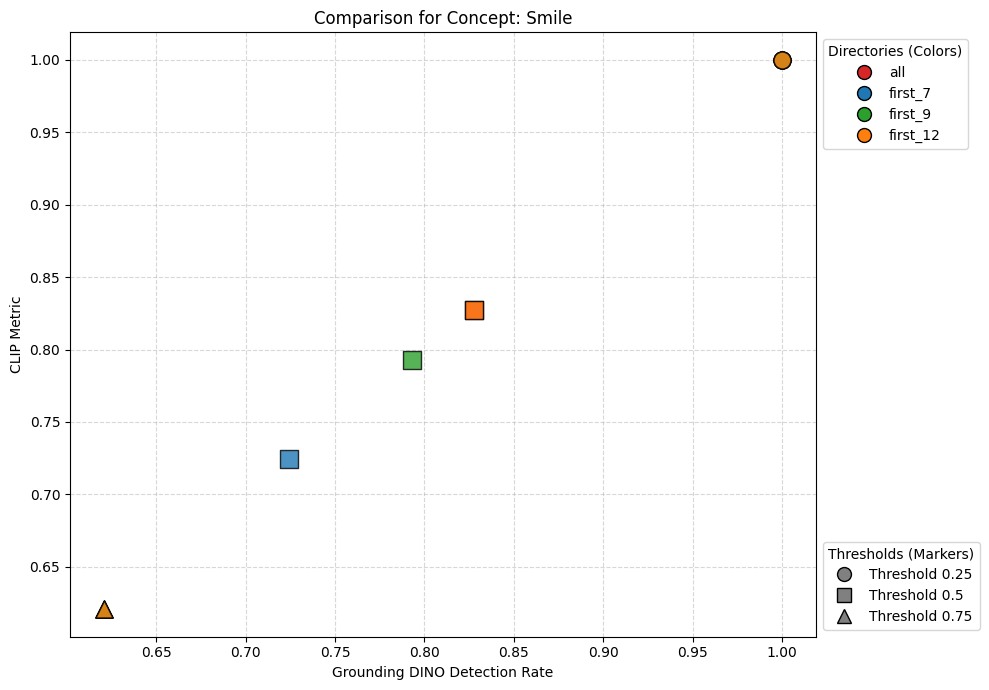

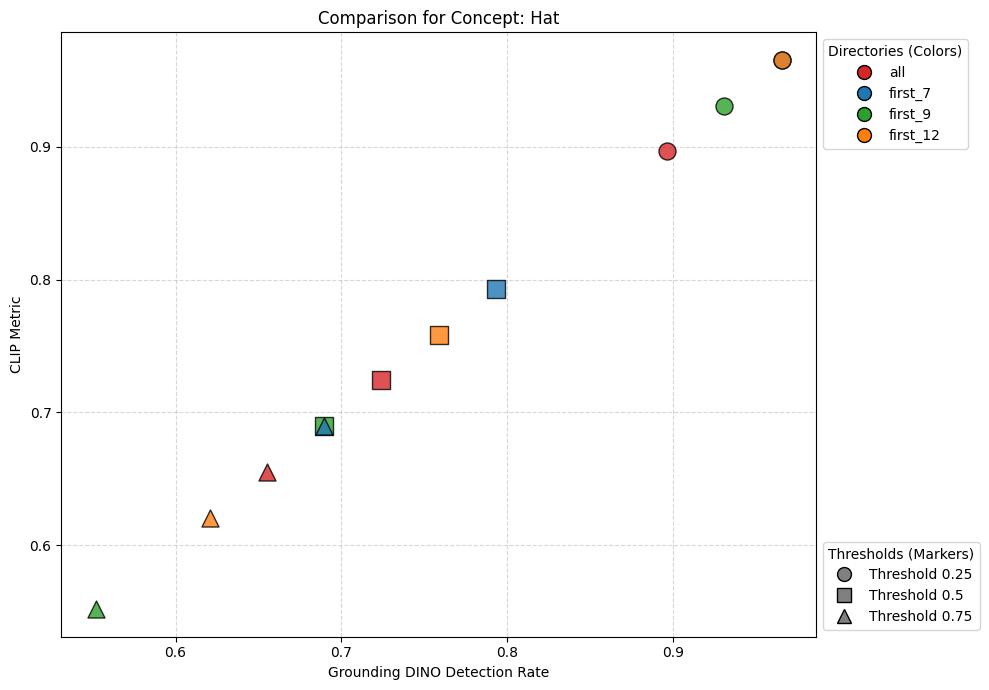

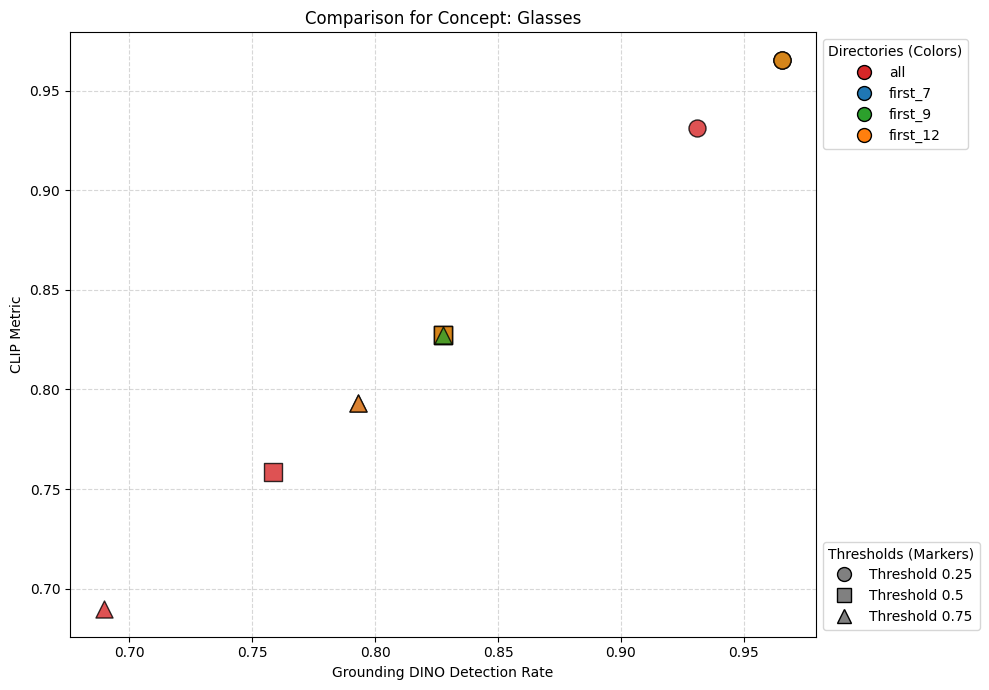

In [21]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Your Data Structures
gd_results = all_dict # Your provided Grounding DINO dict
clip_results = all_dict # Your CLIP dict

# 2. Setup Plotting Parameters
dirs = ['all', 'first_7', 'first_9', 'first_12']
thresholds = ['0.25', '0.5', '0.75']

color_map = {'all': 'tab:red', 'first_7': 'tab:blue', 'first_9': 'tab:green', 'first_12': 'tab:orange'}
marker_map = {'0.25': 'o', '0.5': 's', '0.75': '^'}

# 3. Create Plots for each Concept
for concept in gd_results:
    plt.figure(figsize=(10, 7))
    
    # Iterate through every data point
    for thresh in thresholds:
        for i, d in enumerate(dirs):
            x = gd_results[concept][thresh][i]
            y = clip_results[concept][thresh][i]
            
            plt.scatter(x, y, 
                        color=color_map[d], 
                        marker=marker_map[thresh], 
                        s=150, 
                        edgecolors='black', 
                        alpha=0.8, 
                        zorder=3)
    
    # Define Custom Legends
    color_legend = [Line2D([0], [0], marker='o', color='w', label=d,
                           markerfacecolor=color_map[d], markersize=10, markeredgecolor='k') for d in dirs]
    
    marker_legend = [Line2D([0], [0], marker=marker_map[t], color='w', label=f'Threshold {t}',
                            markerfacecolor='gray', markersize=10, markeredgecolor='k') for t in thresholds]
    
    # Place Legends outside the plot
    l1 = plt.legend(handles=color_legend, title="Directories (Colors)", loc='upper left', bbox_to_anchor=(1, 1))
    plt.gca().add_artist(l1)
    plt.legend(handles=marker_legend, title="Thresholds (Markers)", loc='lower left', bbox_to_anchor=(1, 0))

    # Styling
    plt.title(f"Comparison for Concept: {concept.capitalize()}")
    plt.xlabel("Grounding DINO Detection Rate")
    plt.ylabel("CLIP Metric")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.savefig(f"combined_plot_{concept}.png")